In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
    N_HANKEL_COLS,
    N_HANKEL_ROWS,
    N_BURNIN,
    N_LATENT_PATH,
    N_MARKOV,
    RANDOM_SEED,
)
from era_utils import build_hankel, collect_markov_parameters, estimate_markov_ols
from latent_dim import NOTEBOOK_GITHUB_URL, make_singular_value_figure
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
# Singular values below this fraction of the largest are treated as numerically
# zero in the exact (impulse-subtraction) analysis.
RELATIVE_THRESHOLD    = 1e-6

# System order recoverable from honest data (BIC model selection, N=5000).
N_LATENT_HONEST       = 2

N_SHOW                = 15     # number of singular values to display
DATA_PATH             = N_LATENT_PATH

LATENT_DIM_SEED       = 7      # Brain seed for OLS Markov estimation
LATENT_DIM_DRIVE_SEED = 8      # RNG seed for i.i.d. input sequence
LATENT_DIM_N_SAMPLES  = 5000   # recording length (steps, after burn-in)

In [3]:
# ── derived: Brain interface dimensions ───────────────────────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
Q_DIM = len(_b.measure())
del _b
print(f"n_u = {P_DIM}")
print(f"n_y = {Q_DIM}")

n_u = 2
n_y = 16


In [4]:
# ── simulation: Markov parameters and Hankel singular values ──────────────────
# Exact: same-seed impulse subtraction — not physically realisable but
# establishes the theoretical system order as a reference.
markov_exact = collect_markov_parameters(RANDOM_SEED, P_DIM, N_MARKOV)
H0_exact, _ = build_hankel(markov_exact, N_HANKEL_ROWS, N_HANKEL_COLS)
sv_exact     = np.linalg.svd(H0_exact, compute_uv=False)
SV_EXACT_NORM = sv_exact / sv_exact[0]

# Honest: OLS from a single time series — physically realisable.
markov_ols = estimate_markov_ols(
    LATENT_DIM_SEED, LATENT_DIM_DRIVE_SEED,
    P_DIM, N_MARKOV, LATENT_DIM_N_SAMPLES, N_BURNIN,
)
H0_ols, _ = build_hankel(markov_ols, N_HANKEL_ROWS, N_HANKEL_COLS)
sv_ols     = np.linalg.svd(H0_ols, compute_uv=False)
SV_OLS_NORM = sv_ols / sv_ols[0]

print(f"Hankel matrix shape: {H0_exact.shape}")
print("Normalised singular values — exact | OLS (top 10):")
for i in range(10):
    print(f"  {i + 1:3d}:  {SV_EXACT_NORM[i]:.2e}  |  {SV_OLS_NORM[i]:.2e}")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Hankel matrix shape: (640, 120)
Normalised singular values — exact | OLS (top 10):
    1:  1.00e+00  |  1.00e+00
    2:  2.21e-01  |  3.27e-01
    3:  1.25e-01  |  2.22e-01
    4:  8.73e-02  |  1.87e-01
    5:  9.91e-03  |  1.04e-01
    6:  3.33e-03  |  7.97e-02
    7:  7.74e-16  |  7.91e-02
    8:  4.48e-16  |  7.80e-02
    9:  4.24e-16  |  7.77e-02
   10:  4.00e-16  |  7.69e-02


In [5]:
# ── derive number of latent dimensions ────────────────────────────────────────
N_LATENT = int(np.sum(SV_EXACT_NORM > RELATIVE_THRESHOLD))
print(f"n_x = {N_LATENT}  (exact, threshold = {RELATIVE_THRESHOLD:.0e} × sv[0])")
print(f"n_x = {N_LATENT_HONEST}  (honest, BIC model selection on N={LATENT_DIM_N_SAMPLES} samples)")

n_x = 6  (exact, threshold = 1e-06 × sv[0])
n_x = 2  (honest, BIC model selection on N=5000 samples)


In [6]:
# ── save number of latent dimensions ──────────────────────────────────────────
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(DATA_PATH, n_latent=np.array(N_LATENT))
print(f"Saved n_latent = {N_LATENT} to {DATA_PATH.resolve()}")

Saved n_latent = 6 to /Users/tahmidazam/Developer/gg4/data/latent_dim.npz


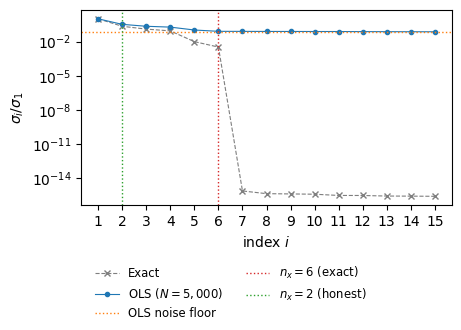

In [7]:
# ── figure: singular value decay ──────────────────────────────────────────────
configure_screen()
fig = make_singular_value_figure(
    SV_EXACT_NORM, SV_OLS_NORM,
    N_LATENT, N_LATENT_HONEST, LATENT_DIM_N_SAMPLES,
    N_SHOW, figsize=(4.5, 3.2),
)
plt.show()

In [8]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.2  # fraction of A4 content height (taller for legend)

configure_pgf()
fig = make_singular_value_figure(
    SV_EXACT_NORM, SV_OLS_NORM,
    N_LATENT, N_LATENT_HONEST, LATENT_DIM_N_SAMPLES,
    N_SHOW, figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "latent_dim.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/latent_dim.pgf


In [9]:
# ── caption ────────────────────────────────────────────────────────────────────
caption = (
    r"Normalised Hankel singular values $\sigma_i / \sigma_1$ for the $"
    + str(N_HANKEL_ROWS)
    + r" \times "
    + str(N_HANKEL_COLS)
    + r"$ block Hankel matrix ($n_u = "
    + str(P_DIM)
    + r"$, $n_y = "
    + str(Q_DIM)
    + r"$). The exact spectrum is obtained by same-seed impulse subtraction,"
    r" which is not physically realisable, and serves as a theoretical reference"
    r" for the true system order. Modes $"
    + str(N_LATENT_HONEST + 1)
    + r"\text{--}"
    + str(N_LATENT)
    + r"$ fall below the OLS noise floor of a "
    + str(LATENT_DIM_N_SAMPLES)
    + r"-step physically realisable recording; BIC model selection on the OLS"
    r" estimates recovers $n_x = "
    + str(N_LATENT_HONEST)
    + r"$."
)
save_caption(CAPTIONS_PATH / "latent_dim.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/latent_dim.tex
Normalised Hankel singular values $\sigma_i / \sigma_1$ for the $40 \times 60$ block Hankel matrix ($n_u = 2$, $n_y = 16$). The exact spectrum is obtained by same-seed impulse subtraction, which is not physically realisable, and serves as a theoretical reference for the true system order. Modes $3\text{--}6$ fall below the OLS noise floor of a 5000-step physically realisable recording; BIC model selection on the OLS estimates recovers $n_x = 2$.
